In [2]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import mean_squared_error

In [6]:
!pip install yfinance

In [8]:
import yfinance as yf 

In [14]:
tickers = ["JPM","AAPL","MSFT","GS","AMZN","META","NVDA","TSLA"]

data = yf.download(tickers, start="2018-01-01", end="2024-01-01")

data.head()

[*********************100%***********************]  8 of 8 completed


Price           Close                                                \
Ticker           AAPL       AMZN          GS        JPM        META   
Date                                                                  
2018-01-02  40.304176  59.450500  213.144257  86.340897  180.161499   
2018-01-03  40.297153  60.209999  211.160110  86.428879  183.388977   
2018-01-04  40.484341  60.479500  214.111313  87.667007  183.051346   
2018-01-05  40.945259  61.457001  213.019196  87.104218  185.553848   
2018-01-08  40.793179  62.343498  209.926315  87.232857  186.973938   

Price                                            High             ...  \
Ticker           MSFT      NVDA       TSLA       AAPL       AMZN  ...   
Date                                                              ...   
2018-01-02  78.870354  4.928533  21.368668  40.313537  59.500000  ...   
2018-01-03  79.237427  5.252898  21.150000  40.839972  60.274502  ...   
2018-01-04  79.934837  5.280587  20.974667  40.587289  60.793499  ...   
2018-01-05  80.925865  5.325338  21.105333  41.031828  61.457001  ...   
2018-01-08  81.008461  5.488509  22.427334  41.087983  62.653999  ...   

Price           Open                Volume                               \
Ticker          NVDA       TSLA       AAPL      AMZN       GS       JPM   
Date                                                                      
2018-01-02  4.840271  20.799999  102223600  53890000  2258300  13578800   
2018-01-03  5.045967  21.400000  118071600  62176000  2988200  11901000   
2018-01-04  5.334236  20.858000   89738400  60442000  2583200  12953700   
2018-01-05  5.295423  21.108000   94640000  70894000  2594700  14155000   
2018-01-08  5.448952  21.066668   82271200  85590000  2940500  12466500   

Price                                                 
Ticker          META      MSFT       NVDA       TSLA  
Date                                                  
2018-01-02  18151900  22483800  355616000   65283000  
2018-01-03  16886600  26061400  914704000   67822500  
2018-01-04  13880900  21912000  583268000  149194500  
2018-01-05  13574500  23407100  580124000   68868000  
2018-01-08  17994700  22113000  881216000  147891000  

[5 rows x 40 columns]

In [16]:
data.columns

MultiIndex([( 'Close', 'AAPL'),
            ( 'Close', 'AMZN'),
            ( 'Close',   'GS'),
            ( 'Close',  'JPM'),
            ( 'Close', 'META'),
            ( 'Close', 'MSFT'),
            ( 'Close', 'NVDA'),
            ( 'Close', 'TSLA'),
            (  'High', 'AAPL'),
            (  'High', 'AMZN'),
            (  'High',   'GS'),
            (  'High',  'JPM'),
            (  'High', 'META'),
            (  'High', 'MSFT'),
            (  'High', 'NVDA'),
            (  'High', 'TSLA'),
            (   'Low', 'AAPL'),
            (   'Low', 'AMZN'),
            (   'Low',   'GS'),
            (   'Low',  'JPM'),
            (   'Low', 'META'),
            (   'Low', 'MSFT'),
            (   'Low', 'NVDA'),
            (   'Low', 'TSLA'),
            (  'Open', 'AAPL'),
            (  'Open', 'AMZN'),
            (  'Open',   'GS'),
            (  'Open',  'JPM'),
            (  'Open', 'META'),
            (  'Open', 'MSFT'),
            (  'Open', 'NVDA'),
        

In [18]:
prices = data["Close"]
prices.head()

Ticker,AAPL,AMZN,GS,JPM,META,MSFT,NVDA,TSLA
Date,,,,,,,,
2018-01-02,40.304176,59.450500,213.144257,86.340897,180.161499,78.870354,4.928533,21.368668
2018-01-03,40.297153,60.209999,211.160110,86.428879,183.388977,79.237427,5.252898,21.150000
2018-01-04,40.484341,60.479500,214.111313,87.667007,183.051346,79.934837,5.280587,20.974667
2018-01-05,40.945259,61.457001,213.019196,87.104218,185.553848,80.925865,5.325338,21.105333
2018-01-08,40.793179,62.343498,209.926315,87.232857,186.973938,81.008461,5.488509,22.427334


In [20]:
returns = prices.pct_change().dropna()

returns.head()

Ticker,AAPL,AMZN,GS,JPM,META,MSFT,NVDA,TSLA
Date,,,,,,,,
2018-01-03,-0.000174,0.012775,-0.009309,0.001019,0.017914,0.004654,0.065814,-0.010233
2018-01-04,0.004645,0.004476,0.013976,0.014325,-0.001841,0.008802,0.005271,-0.008290
2018-01-05,0.011385,0.016163,-0.005101,-0.006420,0.013671,0.012398,0.008475,0.006230
2018-01-08,-0.003714,0.014425,-0.014519,0.001477,0.007653,0.001021,0.030641,0.062638
2018-01-09,-0.000115,0.004676,0.008459,0.005069,-0.002178,-0.000680,-0.000270,-0.008085


In [22]:
portfolio = returns.stack().reset_index()

portfolio.columns = ["date","company","return"]

portfolio.head()

,date,company,return
0,2018-01-03,AAPL,-0.000174
1,2018-01-03,AMZN,0.012775
2,2018-01-03,GS,-0.009309
3,2018-01-03,JPM,0.001019
4,2018-01-03,META,0.017914


In [24]:
np.random.seed(42)

portfolio["loan_amnt"] = np.random.randint(5000,50000,len(portfolio))

portfolio["annual_inc"] = np.random.randint(30000,150000,len(portfolio))

portfolio["credit_score"] = np.random.randint(550,850,len(portfolio))

portfolio["dti"] = np.random.uniform(0,40,len(portfolio))

portfolio["int_rate"] = np.random.uniform(5,20,len(portfolio))

portfolio["recoveries"] = np.random.uniform(0,20000,len(portfolio))

portfolio.head()

,date,company,return,loan_amnt,annual_inc,credit_score,dti,int_rate,recoveries
0,2018-01-03,AAPL,-0.000174,20795,64875,789,19.041706,6.910651,8155.022740
1,2018-01-03,AMZN,0.012775,5860,140049,775,18.675369,11.864634,10540.835053
2,2018-01-03,GS,-0.009309,43158,39465,735,19.700466,12.023046,14805.919472
3,2018-01-03,JPM,0.001019,49732,96095,597,21.427647,17.033950,11919.212690
4,2018-01-03,META,0.017914,16284,103844,757,1.246923,18.742444,5851.257797


In [26]:
default_prob = (
    0.02 +
    (700 - portfolio["credit_score"]) * 0.0005 +
    portfolio["dti"] * 0.002 -
    portfolio["return"] * 0.5
)

In [28]:
portfolio["default_flag"] = np.random.binomial(1, default_prob.clip(0,1))

In [30]:
portfolio["loan_status"] = portfolio["default_flag"].map({
    0: "Fully Paid",
    1: "Charged Off"
})

In [32]:
portfolio.head()

,date,company,return,loan_amnt,annual_inc,credit_score,dti,int_rate,recoveries,default_flag,loan_status
0,2018-01-03,AAPL,-0.000174,20795,64875,789,19.041706,6.910651,8155.022740,0,Fully Paid
1,2018-01-03,AMZN,0.012775,5860,140049,775,18.675369,11.864634,10540.835053,0,Fully Paid
2,2018-01-03,GS,-0.009309,43158,39465,735,19.700466,12.023046,14805.919472,0,Fully Paid
3,2018-01-03,JPM,0.001019,49732,96095,597,21.427647,17.033950,11919.212690,0,Fully Paid
4,2018-01-03,META,0.017914,16284,103844,757,1.246923,18.742444,5851.257797,0,Fully Paid


In [34]:
portfolio["default_flag"].mean()

0.059184350132626

In [36]:
features = [
    "loan_amnt",
    "annual_inc",
    "credit_score",
    "dti",
    "int_rate"
]

X = portfolio[features]
y = portfolio["default_flag"]

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [42]:
from sklearn.linear_model import LogisticRegression

pd_model = LogisticRegression()

pd_model.fit(X_train_scaled, y_train)

LogisticRegression()

In [44]:
pd_predictions = pd_model.predict_proba(X_test_scaled)[:,1]

In [46]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, pd_predictions)

print("ROC AUC:", auc)

ROC AUC: 0.7261947811911651


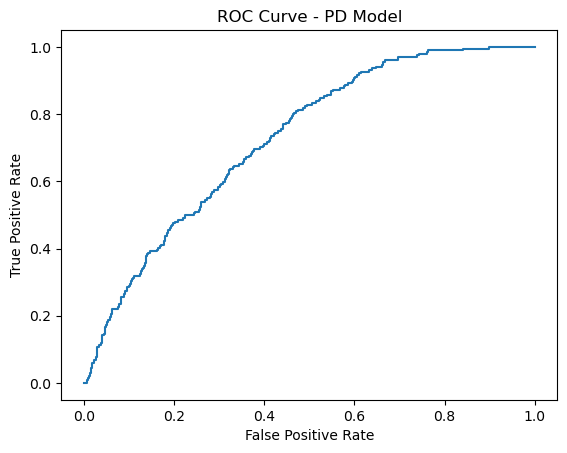

In [48]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, pd_predictions)

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - PD Model")

plt.show()

In [52]:
#LGD = (Exposure − Recovery) / Exposure

In [54]:
portfolio["LGD"] = (portfolio["loan_amnt"] - portfolio["recoveries"]) / portfolio["loan_amnt"]

In [56]:
lgd_data = portfolio[portfolio["default_flag"] == 1]

In [58]:
from sklearn.ensemble import RandomForestRegressor

X_lgd = lgd_data[features]

y_lgd = lgd_data["LGD"]

lgd_model = RandomForestRegressor(n_estimators=100)

lgd_model.fit(X_lgd, y_lgd)

RandomForestRegressor()

In [60]:
portfolio["EAD"] = portfolio["loan_amnt"] * 0.9

In [62]:
X_ead = portfolio[features]

y_ead = portfolio["EAD"]

ead_model = RandomForestRegressor(n_estimators=100)

ead_model.fit(X_ead, y_ead)

RandomForestRegressor()

In [64]:
#Expected Loss = PD × LGD × EAD

In [66]:
expected_loss = pd_predictions * portfolio["LGD"].mean() * portfolio["EAD"].mean()

expected_loss.mean()

734.3679774502915

In [68]:
import pandas as pd

ks_df = pd.DataFrame({
    "y_true": y_test,
    "pd_score": pd_predictions
})

ks_df = ks_df.sort_values("pd_score", ascending=False)

In [70]:
ks_df["bad"] = ks_df["y_true"]
ks_df["good"] = 1 - ks_df["y_true"]

ks_df["cum_bad"] = ks_df["bad"].cumsum() / ks_df["bad"].sum()
ks_df["cum_good"] = ks_df["good"].cumsum() / ks_df["good"].sum()

ks_df["ks"] = ks_df["cum_bad"] - ks_df["cum_good"]

In [72]:
ks_stat = ks_df["ks"].max()

print("KS Statistic:", ks_stat)

KS Statistic: 0.3391938742710199


In [74]:
!pip install scorecardpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for scorecardpy: filename=scorecardpy-0.1.9.7-py3-none-any.whl size=60634 sha256=7f8890d9e2e624548ed54397d3ee286472e9f2f3d468b218006db5c342a1836f
  Stored in directory: /Users/romilmodi/Library/Caches/pip/wheels/9f/d8/4e/61a6f4e78fe6700f66b699ab38377f0aa5b33e3ef55751ba38
Successfully built scorecardpy


In [76]:
import scorecardpy as sc

In [85]:
woe_data = portfolio[features + ["default_flag"]]

woe_data.head()

,loan_amnt,annual_inc,credit_score,dti,int_rate,default_flag
0,20795,64875,789,19.041706,6.910651,0
1,5860,140049,775,18.675369,11.864634,0
2,43158,39465,735,19.700466,12.023046,0
3,49732,96095,597,21.427647,17.033950,0
4,16284,103844,757,1.246923,18.742444,0


In [87]:
woe_data = woe_data.dropna()

In [89]:
woe_data["default_flag"].value_counts()

default_flag
0    11350
1      714
Name: count, dtype: int64

In [91]:
bins = sc.woebin(woe_data, y="default_flag")

[INFO] creating woe binning ...


/opt/anaconda3/lib/python3.12/site-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/opt/anaconda3/lib/python3.12/site-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/opt/anaconda3/lib/python3.12/site-packages/scorecardpy/woebin.py:320: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass o

In [93]:
bins

{'loan_amnt':     variable                bin  count  count_distr  good  bad   badprob  \
 0  loan_amnt     [-inf,10000.0)   1353     0.112152  1272   81  0.059867   
 1  loan_amnt  [10000.0,19000.0)   2420     0.200597  2255  165  0.068182   
 2  loan_amnt  [19000.0,29000.0)   2727     0.226044  2568  159  0.058306   
 3  loan_amnt  [29000.0,37000.0)   2141     0.177470  2032  109  0.050911   
 4  loan_amnt  [37000.0,41000.0)   1051     0.087119   975   76  0.072312   
 5  loan_amnt  [41000.0,45000.0)   1088     0.090186  1025   63  0.057904   
 6  loan_amnt      [45000.0,inf)   1284     0.106432  1223   61  0.047508   
 
         woe    bin_iv  total_iv   breaks  is_special_values  
 0  0.012193  0.000017  0.018806  10000.0              False  
 1  0.151130  0.004899  0.018806  19000.0              False  
 2 -0.015888  0.000057  0.018806  29000.0              False  
 3 -0.159338  0.004202  0.018806  37000.0              False  
 4  0.214386  0.004403  0.018806  41000.0             

In [95]:
woe_df = sc.woebin_ply(woe_data, bins)

[INFO] converting into woe values ...


In [105]:
iv = sc.iv(woe_data, y="default_flag")
iv

,variable,info_value
3,credit_score,0.560025
0,loan_amnt,0.078585
2,annual_inc,0.032315
1,int_rate,0.002475
4,dti,0.002475


In [109]:
def iv_strength(iv):

    if iv < 0.02:
        return "Weak"
    
    elif iv < 0.1:
        return "Medium"
    
    elif iv < 0.3:
        return "Strong"
    
    else:
        return "Very Strong"

In [111]:
iv["strength"] = iv["info_value"].apply(iv_strength)

iv

,variable,info_value,strength
3,credit_score,0.560025,Very Strong
0,loan_amnt,0.078585,Medium
2,annual_inc,0.032315,Medium
1,int_rate,0.002475,Weak
4,dti,0.002475,Weak


In [113]:
iv = iv.sort_values(by="info_value", ascending=False)

iv

,variable,info_value,strength
3,credit_score,0.560025,Very Strong
0,loan_amnt,0.078585,Medium
2,annual_inc,0.032315,Medium
1,int_rate,0.002475,Weak
4,dti,0.002475,Weak


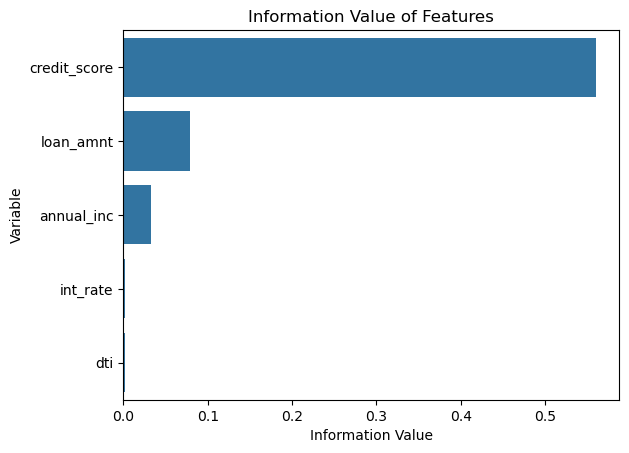

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=iv, x="info_value", y="variable")

plt.title("Information Value of Features")
plt.xlabel("Information Value")
plt.ylabel("Variable")

plt.show()

In [119]:
train_scores = pd_model.predict_proba(X_train_scaled)[:,1]
test_scores = pd_model.predict_proba(X_test_scaled)[:,1]

In [125]:
import numpy as np

def calculate_psi(expected, actual, bins=10):

    breakpoints = np.linspace(0, 1, bins + 1)

    expected_counts = np.histogram(expected, breakpoints)[0]
    actual_counts = np.histogram(actual, breakpoints)[0]

    expected_perc = expected_counts / len(expected)
    actual_perc = actual_counts / len(actual)

    # small value to avoid division by zero
    epsilon = 1e-6

    expected_perc = np.where(expected_perc == 0, epsilon, expected_perc)
    actual_perc = np.where(actual_perc == 0, epsilon, actual_perc)

    psi = np.sum((expected_perc - actual_perc) * np.log(expected_perc / actual_perc))

    return psi

In [127]:
psi_value = calculate_psi(train_scores, test_scores)

print("Population Stability Index:", psi_value)

Population Stability Index: 0.00025175171433521396


In [129]:
if psi_value < 0.1:
    print("Model Stability: Stable")
elif psi_value < 0.25:
    print("Model Stability: Moderate shift")
else:
    print("Model Stability: Significant shift")

Model Stability: Stable


In [131]:
print("MODEL PERFORMANCE SUMMARY")
print("----------------------------------")

print(f"ROC AUC Score (PD Model): {auc:.3f}")
print(f"KS Statistic: {ks_stat:.3f}")
print(f"Population Stability Index (PSI): {psi_value:.3f}")
print(f"Average Expected Loss: {expected_loss.mean():.2f}")

MODEL PERFORMANCE SUMMARY
----------------------------------
ROC AUC Score (PD Model): 0.726
KS Statistic: 0.339
Population Stability Index (PSI): 0.000
Average Expected Loss: 734.37


In [133]:
importance = pd.Series(
    pd_model.coef_[0],
    index=features
).sort_values(ascending=False)

print("Key Risk Drivers:")
print(importance)

Key Risk Drivers:
dti             0.417282
annual_inc      0.033195
int_rate       -0.042164
loan_amnt      -0.073774
credit_score   -0.765652
dtype: float64


In [135]:
print("Top Predictive Variables Based on IV")

print(iv[["variable","info_value","strength"]])

Top Predictive Variables Based on IV
       variable  info_value     strength
3  credit_score    0.560025  Very Strong
0     loan_amnt    0.078585       Medium
2    annual_inc    0.032315       Medium
1      int_rate    0.002475         Weak
4           dti    0.002475         Weak


In [139]:

stress_pd = pd_predictions * 1.5
stress_pd = np.clip(stress_pd, 0, 1)
stress_el = stress_pd * portfolio["LGD"].mean() * portfolio["EAD"].mean()

baseline_el = expected_loss.mean()
stress_el_mean = stress_el.mean()

print("Baseline Expected Loss:", baseline_el)
print("Stress Expected Loss:", stress_el_mean)



Baseline Expected Loss: 734.3679774502915
Stress Expected Loss: 1101.5519661754372


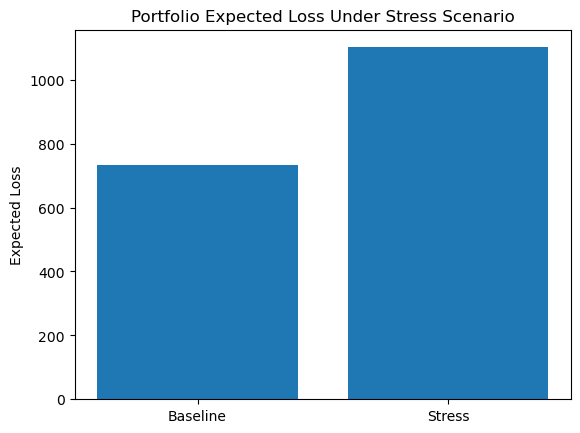

In [141]:
import matplotlib.pyplot as plt

plt.bar(["Baseline","Stress"], [baseline_el, stress_el_mean])

plt.title("Portfolio Expected Loss Under Stress Scenario")
plt.ylabel("Expected Loss")

plt.show()

In [143]:
print(f"Stress Scenario Loss: {stress_el_mean:.2f}")

Stress Scenario Loss: 1101.55


In [145]:
decile_df = pd.DataFrame({
    "actual_default": y_test,
    "pd_score": pd_predictions
})

In [147]:
decile_df = decile_df.sort_values("pd_score", ascending=False)

In [149]:
decile_df["decile"] = pd.qcut(decile_df["pd_score"], 10, labels=False)

In [151]:
decile_df["decile"] = 10 - decile_df["decile"]

In [153]:
decile_table = decile_df.groupby("decile").agg(
    
    total_loans=("actual_default","count"),
    defaults=("actual_default","sum"),
    
)

decile_table["default_rate"] = decile_table["defaults"] / decile_table["total_loans"]

decile_table = decile_table.sort_index()

decile_table

,total_loans,defaults,default_rate
decile,,,
1,362,54,0.149171
2,362,37,0.102210
3,362,24,0.066298
4,362,27,0.074586
5,362,24,0.066298
6,362,15,0.041436
7,362,15,0.041436
8,362,6,0.016575
9,362,1,0.002762


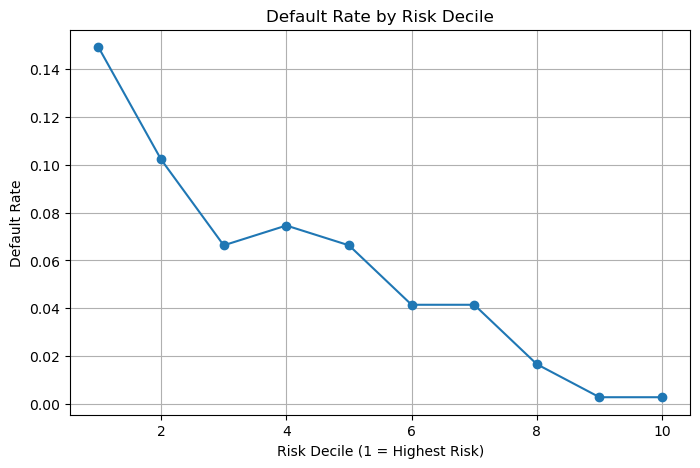

In [155]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(decile_table.index, decile_table["default_rate"], marker="o")

plt.title("Default Rate by Risk Decile")
plt.xlabel("Risk Decile (1 = Highest Risk)")
plt.ylabel("Default Rate")

plt.grid(True)

plt.show()

In [157]:
overall_default_rate = decile_df["actual_default"].mean()

decile_table["lift"] = decile_table["default_rate"] / overall_default_rate

decile_table

,total_loans,defaults,default_rate,lift
decile,,,,
1,362,54,0.149171,2.647059
2,362,37,0.102210,1.813725
3,362,24,0.066298,1.176471
4,362,27,0.074586,1.323529
5,362,24,0.066298,1.176471
6,362,15,0.041436,0.735294
7,362,15,0.041436,0.735294
8,362,6,0.016575,0.294118
9,362,1,0.002762,0.049020


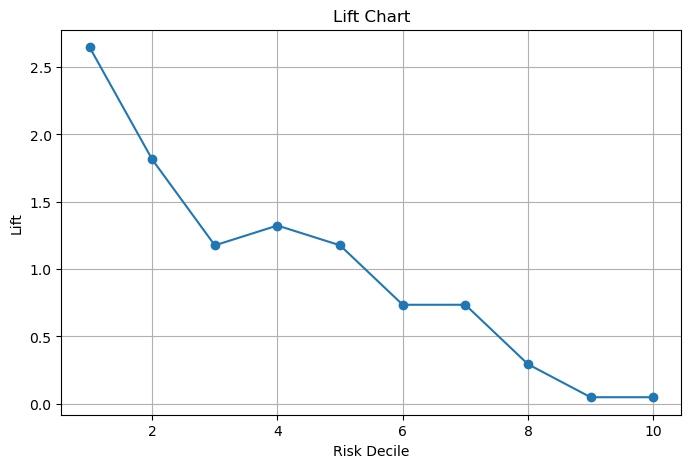

In [159]:
plt.figure(figsize=(8,5))

plt.plot(decile_table.index, decile_table["lift"], marker="o")

plt.title("Lift Chart")
plt.xlabel("Risk Decile")
plt.ylabel("Lift")

plt.grid(True)

plt.show()

In [161]:
print("DECILE ANALYSIS INSIGHTS")
print("----------------------------------")

print("1. The model successfully ranks borrowers by credit risk.")
print("2. The highest risk decile shows significantly higher default rates.")
print("3. Lift analysis indicates strong discriminatory power of the model.")
print("4. The PD model effectively identifies high-risk borrowers for credit decisioning.")

DECILE ANALYSIS INSIGHTS
----------------------------------
1. The model successfully ranks borrowers by credit risk.
2. The highest risk decile shows significantly higher default rates.
3. Lift analysis indicates strong discriminatory power of the model.
4. The PD model effectively identifies high-risk borrowers for credit decisioning.


In [163]:
# Data ingestion (yfinance)
# Feature engineering
# PD model
# LGD model
# EAD model
# Expected loss framework
# KS statistic
# WOE + IV analysis
# PSI stability test
# Macroeconomic stress testing
# Decile analysis
# Lift chart